In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert target column
df["Churn_Label"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Save cleaned data
df.to_csv("cleaned_churn_data.csv", index=False)

print("Cleaned churn data saved successfully")

Cleaned churn data saved successfully


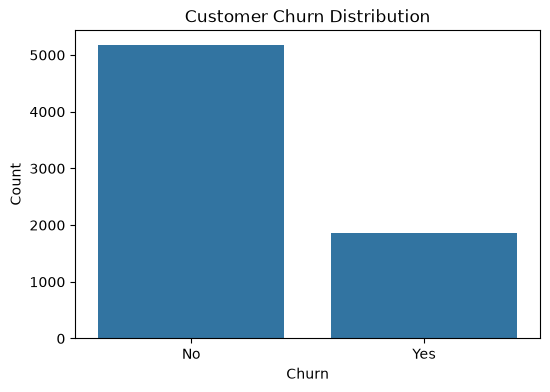

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

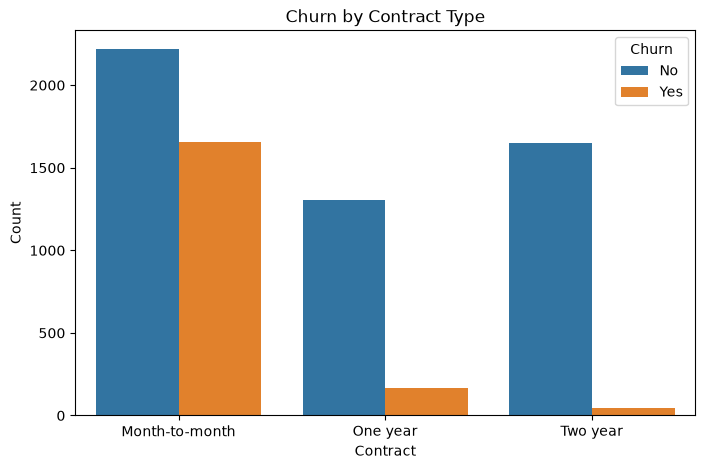

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

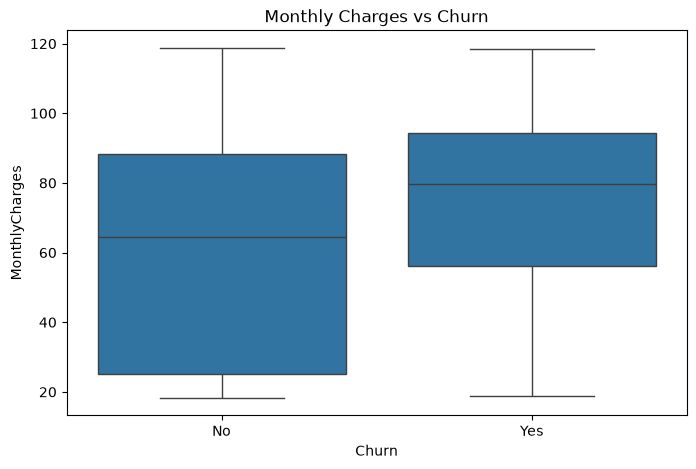

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

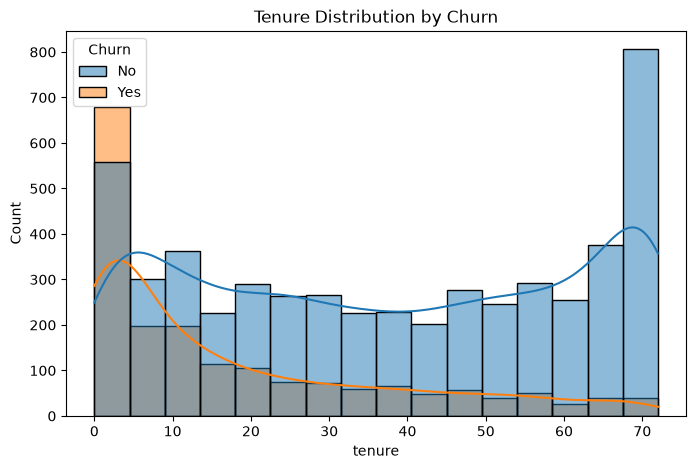

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

In [8]:
total_customers = len(df)
churned_customers = df[df["Churn"] == "Yes"].shape[0]
retained_customers = df[df["Churn"] == "No"].shape[0]
churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %


In [9]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [10]:
df.groupby("InternetService")["Churn_Label"].mean() * 100

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_Label, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Drop unnecessary columns
X = df.drop(["customerID", "Churn", "Churn_Label"], axis=1)
y = df["Churn_Label"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12420\216020950.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Accuracy: 0.8055358410220014
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



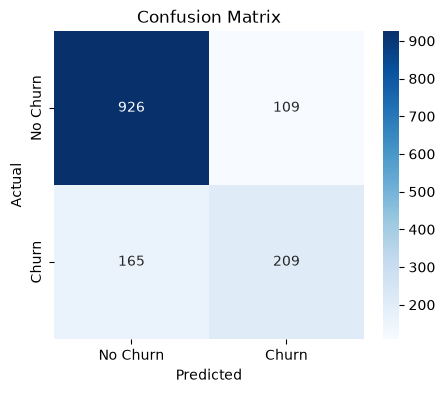

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
joblib.dump(model, "churn_prediction_model.pkl")

print("Model saved successfully")

Model saved successfully


In [14]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0][1]

if prediction == 1:
    print("Customer is likely to churn")
else:
    print("Customer is not likely to churn")

print("Churn Probability:", round(probability * 100, 2), "%")

Customer is not likely to churn
Churn Probability: 4.52 %
